<div style="text-align: center; font-weight: bold;">
    <h1>Getting Started: EHR Data Overview and Exploration</h1>
    <h4>Author: Vidul Ayakulangara Panickan</h4>
</div>

## Goal

Explore MIMIC-IV 3.1 EHR data and generate summary statistics for five data types: diagnoses, HCPCS procedures, ICD procedures, prescriptions, and laboratory tests.

**How the Tutorial is Structured**  

This tutorial is divided into four parts.  

- **Part 1: Data Cleaning** - Assess missingness, filter columns, standardize schema, remove duplicates
- **Part 2: Medical Code Rollup** - Map granular EHR codes to standardized parent codes
- **Part 3: Natural Language Processing** - Convert clinical notes to UMLS CUI codes
- **Part 4: Cohort Creation** - Define patient cohorts and aggregate data into patient-level count matrices

In each part, we will walk through the key steps using MIMIC-IV datasets as examples and then define reusable functions that encompass these steps, allowing them to be applied to other MIMIC-IV datasets.

**Prerequisites:**  
1. Python programming basics and Pandas library
2. Access to Medical Information Mart for Intensive Care data ([MIMIC-IV 3.1](https://physionet.org/content/mimiciv/3.1/))
3. A [UMLS](https://www.nlm.nih.gov/research/umls/index.html) account

## Environment Setup

Before running this notebook, complete the workspace setup, data download, and unzipping in the [Environment Setup](EHR_Preprocessing_Environment_Setup.ipynb) notebook.

Once your workspace is ready, continue below.

Once MIMIC is downloaded, you are ready to work on this notebook. We begin by importing the required libraries and setting up the workspace path.

In [ ]:
import os
import pandas as pd
from tqdm import tqdm                # Progress bars for long operations
from wordcloud import WordCloud      # Visualize most frequent codes
import matplotlib.pyplot as plt

# UPDATE THIS to your EHR_TUTORIAL_WORKSPACE path
base_dir = "EHR_TUTORIAL_WORKSPACE"

We create a directory to store the summary files we will generate throughout this notebook.

In [ ]:
summary_dir = os.path.join(base_dir, 'processed_data', 'Summary')
os.makedirs(summary_dir, exist_ok=True)
print(f"Summary directory: {summary_dir}")

## EHR Data Overview

After gaining access, it is essential to develop a thorough understanding of the EHR data to assemble the elements of interest and create a dataset aligned with the research objectives. This typically involves answering the following questions:

1. **What data is available, and where is it stored?**
2. **Which data elements are relevant, and how are they defined?**
3. **How is the data organized and linked across files and tables?**

These questions are typically addressed by consulting institution specific EHR documentation or the warehouse data manager. For MIMIC-IV, comprehensive documentation is available on the project website [here](https://mimic.mit.edu/docs/iv/).

For users new to EHR data, we highly recommend watching the MIMIC data tutorial [here](https://mimic.mit.edu/docs/iv/tutorials/video/).

#### What data is available and where is it stored?
Electronic Health Record (EHR) data can take many forms: tabular billing data, free-text clinical notes, waveform recordings, and medical images. These data originate from various systems within the hospital. Today, several frameworks facilitate clinical research using EHR data such as the [i2b2](https://community.i2b2.org/wiki/display/BUN/2.+Quick+Start+Guide) framework from MGB and Harvard and [VINCI](https://www.research.va.gov/programs/vinci/), maintained by Veterans Affairs, which provide both data and analytical tools to support research and analysis.

EHR data is typically stored in databases. In this tutorial, we will be working with MIMIC data stored as flat files. MIMIC-IV data comes in "modules" based on the source of data generation:

- [hosp](https://mimic.mit.edu/docs/iv/modules/hosp/) - Hospital-level data for patients, including labs, microbiology, and electronic medication administration records.  
- [icu](https://mimic.mit.edu/docs/iv/modules/icu/) - ICU-level data, including event tables (e.g., chart events) identical in structure to MIMIC-III.  
- [ed](https://mimic.mit.edu/docs/iv/modules/ed/) - Data from the emergency department.  
- [cxr](https://mimic.mit.edu/docs/iv/modules/cxr/) - Lookup tables and metadata from MIMIC-CXR, enabling linkage to MIMIC-IV.  
- [note](https://physionet.org/content/mimic-iv-note/2.2/) - De-identified free-text clinical notes.  

**In this tutorial, we will work with the `hosp` and `note` modules.** The table below shows the data types from these two modules that we will use:

| Data type            | Data contents                          | Module | Major tables                                   | Primary timestamps            |
|----------------------|--------------------------------------------|--------|----------------------------------------------------------|---------------------------------|
| Diagnoses            | ICD-9/10 diagnosis codes per admission     | hosp   | `diagnoses_icd`, `d_icd_diagnoses`                       | Admission window (`admittime`, `dischtime`) |
| Procedures           | ICD-9/10-PCS, CPT/HCPCS events             | hosp   | `procedures_icd`, `hcpcsevents`, `d_icd_procedures`, `d_hcpcs` | Admission window; event dates (if present) |
| Medications          | Orders & administrations                   | hosp   | `prescriptions`, `emar`, `emar_detail`                   | `starttime`, `stoptime`, `charttime`        |
| Laboratory results   | Results + units                            | hosp   | `labevents`, `d_labitems`                                | `charttime`                      |
| Clinical notes       | Discharge, radiology, etc. (text)          | note   | `note`                                                   | `charttime` (or note time)       |

#### Which data elements are relevant, and how are they defined?

Across all EHR tables, three key data elements form the foundation of most analyses:

| Key data element   | Description                                             | Examples in MIMIC-IV                                                                                 |
|--------------------|---------------------------------------------------------|-------------------------------------------------------------------------------------------------------|
| Unique Patient ID  | Patient identifier used across all tables and encounters| `subject_id`                                                                                          |
| Event              | A clinical record that something happened/was recorded  | Diagnoses (`diagnoses_icd`); Meds (`prescriptions`); Labs (`labevents`); Procedures (`procedures_icd`, `hcpcsevents`) |
| Time               | When the event occurred or was recorded                 | Event times (`charttime`, `starttime`, `stoptime`); admission window (`admittime`, `dischtime`) from `admissions`      |

From all the tables in the `hosp` module, we will use the following in this tutorial:

| Type           | Table                | Purpose / contents                                                    | Primary code fields              | Typical join keys                 |
|-------------------|----------------------|------------------------------------------------------------------------|----------------------------------|-----------------------------------|
| Data Dictionary   | `d_hcpcs`            | CPT/HCPCS code definitions                                            | `hcpcs_cd`                       | Link to `hcpcsevents.hcpcs_cd`    |
| Data Dictionary   | `d_icd_diagnoses`    | ICD-9/10 diagnosis code definitions                                   | `icd_code`, `icd_version`       | Link to `diagnoses_icd`           |
| Data Dictionary   | `d_icd_procedures`   | ICD-9/10 procedure code definitions                                   | `icd_code`, `icd_version`       | Link to `procedures_icd`          |
| Data Dictionary   | `d_labitems`         | Lab item dictionary (labels, categories, units metadata)              | `itemid`                         | Link to `labevents.itemid`        |
| Event Table       | `diagnoses_icd`      | Billed ICD diagnosis codes per hospitalization                        | `icd_code`, `icd_version`       | `subject_id`, `hadm_id`           |
| Event Table       | `prescriptions`      | Medication orders                                                      | `ndc`                            | `subject_id`, `hadm_id`           |
| Event Table       | `labevents`          | Laboratory measurements (values + units)                              | `itemid`                         | `subject_id`, `hadm_id`           |
| Event Table       | `hcpcsevents`        | CPT/HCPCS billed events during hospitalization                        | `hcpcs_cd`                       | `subject_id`, `hadm_id`           |
| Event Table       | `procedures_icd`     | ICD-9/10-PCS billed procedures                                        | `icd_code`, `icd_version`       | `subject_id`, `hadm_id`           |
| Patient Metadata  | `patients`           | Demographics and anchor fields                                        | —                                | `subject_id`                      |

More information on all tables in the hosp module can be found in the [MIMIC-IV documentation](https://mimic.mit.edu/docs/iv/modules/hosp/).

#### How is the data organized and linked across files and tables?

In EHR data, information can be spread across multiple tables or datasets. You will need to link data from different tables to create a comprehensive dataset depending on your research needs. One of the key aspects for linking data is identifiers. The following three major identifiers are used in MIMIC data. 

- **`SUBJECT_ID`**: This is a patient level identifier. The patients table contains demographics for each unique patient
- **`HADM_ID`**: This is a hospital level identifier provided in the hosp module. Each unique hospital admission for a patient gets a unique id.
- **`STAY_ID`**: All ICU admissions within 24 hours of each other are grouped and assigned an identifier.


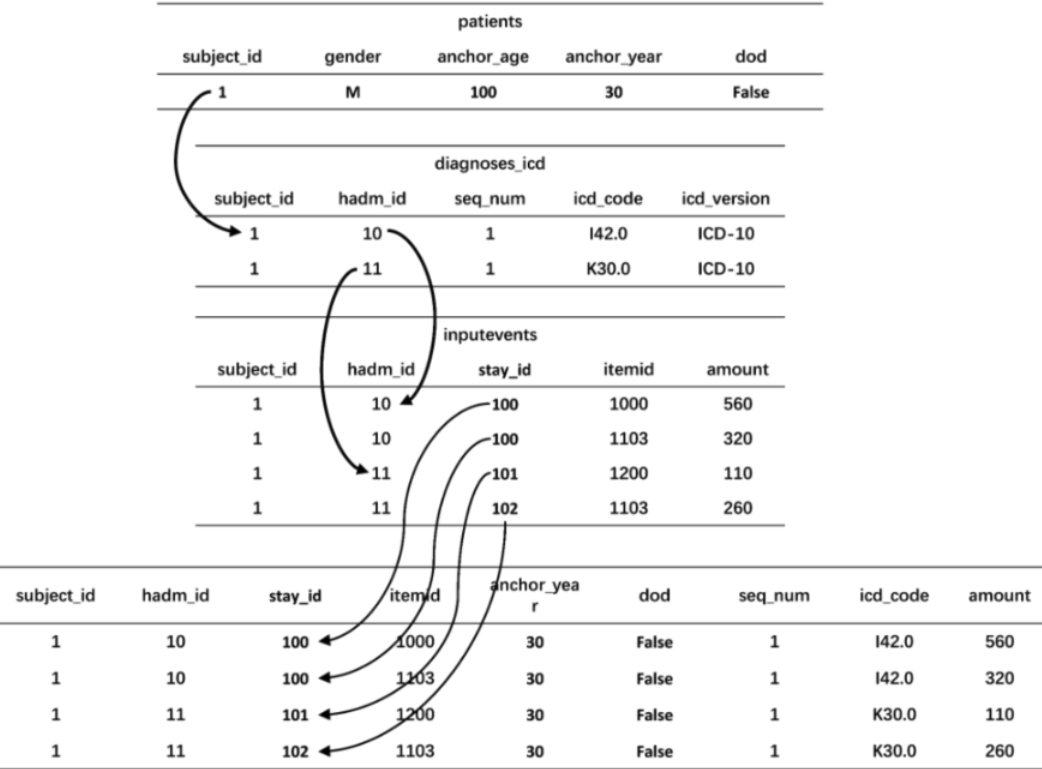

#### Key Coding Systems

Before we explore the data, here are the major coding systems you will encounter in this tutorial:

- **ICD (International Classification of Diseases):** A standardized system for coding diagnoses and procedures. ICD-9 was used in the U.S. until October 1, 2015, and ICD-10 has been used since. The same condition will have different codes depending on which version was in effect when the encounter was recorded.
- **CPT/HCPCS (Current Procedural Terminology / Healthcare Common Procedure Coding System):** Billing codes for medical services and procedures.
- **NDC (National Drug Code):** A unique identifier for medications in the U.S., covering manufacturer, product, and package.
- **ITEMID:** A MIMIC-specific identifier for laboratory tests, mapped to human-readable labels in the `d_labitems` dictionary table.

MIMIC-IV also provides **data dictionary tables** (prefixed with `d_`) that map codes to human-readable descriptions. For example, `d_icd_diagnoses` maps ICD codes to their full diagnostic names.

## Exploring Patient Demographics

We begin by loading and exploring the patients table to understand the population in MIMIC-IV.

Load the patients table. We read all columns as strings to keep data types consistent throughout the pipeline.

In [ ]:
demographics_file = os.path.join(base_dir, "raw_data", "structured_data", "physionet.org", "files", "mimiciv", "3.1", "hosp", "patients.csv")
demographics = pd.read_csv(demographics_file, dtype=str)
print(f"Demographics shape: {demographics.shape}")
display(demographics.head())

Check basic statistics and identify any missing values. Since all columns are loaded as strings, `describe()` shows `unique` (number of distinct values), `top` (most frequent value), and `freq` (how often it appears) instead of numeric statistics like `mean` or `std`.

In [ ]:
display(demographics.describe())
print("\nMissing records in the Demographics table:")
print(demographics.isna().sum())

There are a total of `364,627` patients in the MIMIC-IV hospital dataset. The `describe()` output tells us that there are 2 unique genders (F/M), with Female (`F`) being the most frequent. The most common anchor age is `0`, appearing in 141,474 records — these represent patients seen only in the emergency department without a hospital admission.

Plot the age distribution across all patients.

In [ ]:
age_counts = demographics['anchor_age'].value_counts().sort_index()
plt.figure(figsize=[12, 8])
plt.bar(age_counts.index, age_counts.values, color='skyblue')
plt.xticks(range(0, 100, 10))
plt.xlabel('Age (years)')
plt.ylabel('Number of Patients')
plt.title('Patient Age Distribution')
plt.show()

Plot the gender distribution.

In [ ]:
gender_counts = demographics['gender'].value_counts()
colors = gender_counts.index.map({'F': 'lightpink', 'M': 'lightblue'})
plt.figure(figsize=(8, 6))
plt.bar(gender_counts.index, gender_counts.values, color=colors)
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.title('Patient Gender Distribution')
plt.show()

Around `52%` of the patient cohort are female. We observe that there is no age data for patients with age < 18, and there is a spike at age 91. This is because ages over 89 are depicted as 90+ or as a median value above 90 to comply with HIPAA privacy regulations. The age and gender demographics can vary depending on the healthcare institution. For example, at a Veterans hospital, you typically see a larger male population and a higher average age, while at a Children's hospital, the patient population is much younger.

Now that we understand who the patients are, let's explore what conditions they were diagnosed with. We will walk through each step of summarizing an EHR table using diagnoses as our example, then wrap those steps into a reusable function.

## Step-by-Step: Exploring Diagnoses Data

In U.S. healthcare systems, diagnoses are primarily documented using **ICD (International Classification of Diseases)** codes. There are two versions in use:
- **ICD-9**: used until **October 1, 2015**  
- **ICD-10**: starting **October 1, 2015**

The same diagnosis will be represented using different codes depending on whether it was recorded before or after the transition. For a detailed comparison, you can read more [here](https://www.ama-assn.org/media/7546/download).

We will now walk through the complete process of summarizing an EHR table step by step. After understanding each step, we will wrap them into a reusable function.

**Step 1: Load the data.** We load `diagnoses_icd.csv`, which contains one row per diagnosis code per hospital admission.

In [ ]:
hosp_path = os.path.join(base_dir, "raw_data", "structured_data", "physionet.org", "files", "mimiciv", "3.1", "hosp")
diagnoses_file = os.path.join(hosp_path, "diagnoses_icd.csv")
diagnoses = pd.read_csv(diagnoses_file, dtype=str)
print(f"Shape: {diagnoses.shape}")
display(diagnoses.head())

**Step 2: Summarize the table.** We use `describe()` to get a quick overview. Since all columns are strings, the output shows the number of unique values and the most frequent value for each column.

In [ ]:
display(diagnoses.describe())

There are **`6,364,488`** total records across **`223,291`** unique patients. This is **`61%`** of the 364,627 patients we saw in the demographics table. The discrepancy exists because the remaining patients were seen only in the emergency department and never had a hospital admission. This tutorial focuses on hospitalized patients.

It is crucial to identify and account for every medical code in the EHR data, as overlooking them can compromise the results of your analysis.

**Step 3: Find the most frequent ICD codes.** We use `value_counts()` to count how often each code appears, then take the top 5.

In [ ]:
top_icd_codes = diagnoses['icd_code'].value_counts().head(5).reset_index()
top_icd_codes.columns = ['icd_code', 'record_count']
display(top_icd_codes)

The most frequent code is `4019` with over 100,000 records. But how many **unique patients** have each code? A single patient may have the same diagnosis recorded across multiple admissions. To count patients rather than records, we need to deduplicate.

**Step 4: Count unique patients per code.** We group by ICD code and version, then count distinct patients using `nunique()`.

In [ ]:
patient_counts = (
    diagnoses
    .groupby(['icd_code', 'icd_version'])['subject_id']
    .nunique()
    .reset_index(name='patient_count')
    .sort_values('patient_count', ascending=False)
)
print(f"Unique code-version pairs: {patient_counts.shape[0]}")
display(patient_counts.head())

We now know that roughly 52,000 patients have ICD-9 code `4019` and 48,000 have ICD-10 code `I10`. But what do these codes mean? We need to look them up in the **data dictionary** table. In MIMIC-IV, tables prefixed with `d_` contain code definitions — for example, `d_icd_diagnoses` maps ICD codes to their full diagnostic names.

**Step 5: Merge with the data dictionary** to get human-readable code descriptions.

In [ ]:
icd_dict = pd.read_csv(os.path.join(hosp_path, "d_icd_diagnoses.csv"), dtype=str)
print(f"Patient counts shape before merge: {patient_counts.shape}")
patient_counts_with_names = patient_counts.merge(
    icd_dict[['icd_code', 'icd_version', 'long_title']],
    on=['icd_code', 'icd_version'], how='left'
)
print(f"Patient counts shape after merge: {patient_counts_with_names.shape}")
display(patient_counts_with_names.head())

Now we can see that `4019` = "Unspecified essential hypertension" (ICD-9) and `I10` = "Essential (primary) hypertension" (ICD-10). Both represent hypertension — the same condition coded differently before and after October 2015. We save these results for reference.

In [ ]:
patient_counts_with_names.to_csv(os.path.join(summary_dir, "diagnoses_patient_counts.csv"), index=False)
print(f"Saved {len(patient_counts_with_names)} rows to diagnoses_patient_counts.csv")

**Step 6: Visualize with a word cloud.** A word cloud shows the most frequent diagnoses with larger text for more common conditions. We build a dictionary mapping each diagnosis name to its patient count, then pass it to `WordCloud`.

In [ ]:
word_freq = {}
for name, count in zip(patient_counts_with_names['long_title'].astype(str), 
                        patient_counts_with_names['patient_count']):
    word_freq[name] = count

wordcloud = WordCloud(
    width=1200, height=800, background_color='white',
    colormap='viridis', max_words=100
).generate_from_frequencies(word_freq)

Display the word cloud. Larger words represent diagnoses that appear in more patients.

In [ ]:
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()
wordcloud.to_file(os.path.join(summary_dir, "diagnoses_icd_wordcloud.png"))

### <span style="color: #d9534f;">Important Note on ICD Code Transition</span>

If you observe the top two most frequent codes, you will see both correspond to hypertension. Essential hypertension is coded as `4019` under ICD-9 and `I10` under ICD-10. If your study spans the transition period, you must include both code sets to avoid undercounting patients with a given condition. We will address this systematically in the **Code Rollup** notebook.

## Building a Reusable Summary Function

We just walked through six steps to summarize the diagnoses table. Now we want to repeat this for HCPCS procedures, ICD procedures, prescriptions, and lab tests. Instead of copy-pasting the same code, we wrap our steps into a reusable function.

One key difference: the diagnoses table (6M rows) fits entirely in memory, but larger tables like `labevents` (100M+ rows) do not. Our function handles this by reading the file in **batches** — processing a few million rows at a time and combining the results.

The function `summarize_ehr_table` takes a data file and a code dictionary, then:
1. Reads the file in batches, collecting unique patient-code pairs from each batch
2. Combines and deduplicates across all batches
3. Counts how many unique patients have each code
4. Merges with the data dictionary for human-readable descriptions
5. Saves results and generates a word cloud

The `code_version_col` parameter is optional — it is only needed for ICD data where codes come in two versions (ICD-9 and ICD-10).

In [ ]:
def summarize_ehr_table(filepath, code_dictionary, patient_col, code_col, desc_col,
                        summary_dir, batch_size=5000000, code_version_col=None):
    """
    Summarize an EHR table: count unique patients per code, merge with
    a data dictionary for descriptions, and generate a word cloud.
    Reads data in batches to handle files too large for memory.
    """
    filename = os.path.splitext(os.path.basename(filepath))[0]
    
    # Build the list of columns we need to read
    code_cols = [code_col]
    if code_version_col:
        code_cols.append(code_version_col)
    cols_to_read = [patient_col] + code_cols
    
    # Step 1: Read in batches, collect unique patient-code pairs from each batch
    all_pairs = []
    total_rows = 0
    for batch in tqdm(pd.read_csv(filepath, usecols=cols_to_read, chunksize=batch_size, dtype=str),
                      desc=f"Reading {filename}"):
        total_rows += len(batch)
        # Deduplicate within each batch to save memory before combining
        unique_in_batch = batch.drop_duplicates()
        all_pairs.append(unique_in_batch)
    print(f"Total rows in {filename}: {total_rows:,}")
    
    # Step 2: Combine all batches and remove duplicates that span batch boundaries
    all_unique_pairs = pd.concat(all_pairs, ignore_index=True).drop_duplicates()
    
    # Step 3: Count unique patients per code
    patient_counts = (
        all_unique_pairs
        .groupby(code_cols)[patient_col]
        .nunique()
        .reset_index(name='patient_count')
        .sort_values('patient_count', ascending=False)
    )
    
    # Step 4: Merge with dictionary to get human-readable descriptions
    print(f"Shape before merge: {patient_counts.shape}")
    result = patient_counts.merge(code_dictionary, on=code_cols, how='left')
    print(f"Shape after merge:  {result.shape}")
    display(result.head(10))
    
    # Save patient counts with descriptions
    output_path = os.path.join(summary_dir, f"{filename}_patient_counts.csv")
    result.to_csv(output_path, index=False)
    
    # Step 5: Generate and save word cloud
    word_freq = {}
    for name, count in zip(result[desc_col].astype(str), result['patient_count']):
        word_freq[name] = count
    
    wordcloud = WordCloud(
        width=1200, height=800, background_color='white',
        colormap='viridis', max_words=100
    ).generate_from_frequencies(word_freq)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.tight_layout(pad=0)
    plt.show()
    wordcloud.to_file(os.path.join(summary_dir, f"{filename}_wordcloud.png"))
    
    print(f"Saved: {filename}_patient_counts.csv, {filename}_wordcloud.png")

## Summarizing Remaining Data Types

We now apply `summarize_ehr_table` to the four remaining datasets in the MIMIC-IV hosp module. Each call loads a data dictionary table (prefixed with `d_`) and runs the full summarization pipeline.

### HCPCS Procedures

HCPCS (Healthcare Common Procedure Coding System) codes capture billed services and procedures during hospitalization, including CPT codes for medical services.

In [ ]:
hcpcs_dict = pd.read_csv(os.path.join(hosp_path, "d_hcpcs.csv"), dtype=str)
hcpcs_dict = hcpcs_dict.rename(columns={"code": "hcpcs_cd"})

summarize_ehr_table(
    os.path.join(hosp_path, "hcpcsevents.csv"), hcpcs_dict,
    patient_col="subject_id", code_col="hcpcs_cd",
    desc_col="short_description", summary_dir=summary_dir
)

### ICD Procedures

ICD procedure codes (ICD-9-PCS and ICD-10-PCS) capture billed procedures performed during hospitalization, such as surgeries and therapeutic interventions.

In [ ]:
icd_proc_dict = pd.read_csv(os.path.join(hosp_path, "d_icd_procedures.csv"), dtype=str)

summarize_ehr_table(
    os.path.join(hosp_path, "procedures_icd.csv"), icd_proc_dict,
    patient_col="subject_id", code_col="icd_code", desc_col="long_title",
    summary_dir=summary_dir, code_version_col="icd_version"
)

### Prescriptions (Medications)

Prescriptions are identified by NDC (National Drug Code). Unlike the other datasets, there is no separate data dictionary file for NDC codes, so we construct one from the `ndc`-`drug` mapping within the prescriptions file itself.

In [ ]:
prescriptions_file = os.path.join(hosp_path, "prescriptions.csv")
ndc_dict = pd.read_csv(prescriptions_file, dtype=str, usecols=['ndc', 'drug'])
print(f"NDC-drug pairs before dedup: {ndc_dict.shape}")
ndc_dict = ndc_dict.drop_duplicates(subset=['ndc'], keep='first')
print(f"NDC-drug pairs after dedup: {ndc_dict.shape}")

Run the summary using the NDC dictionary we just built.

In [ ]:
summarize_ehr_table(
    prescriptions_file, ndc_dict,
    patient_col="subject_id", code_col="ndc",
    desc_col="drug", summary_dir=summary_dir
)

### Laboratory Tests

Lab events are identified by `itemid`, a MIMIC-specific identifier mapped to test names in the `d_labitems` dictionary. This is the largest dataset in the hosp module, so we increase the batch size to 15 million rows.

In [ ]:
lab_dict = pd.read_csv(os.path.join(hosp_path, "d_labitems.csv"), dtype=str)
display(lab_dict.head())

Run the summary with a larger batch size for this 100M+ row dataset.

In [ ]:
summarize_ehr_table(
    os.path.join(hosp_path, "labevents.csv"), lab_dict,
    patient_col="subject_id", code_col="itemid",
    desc_col="label", summary_dir=summary_dir, batch_size=15000000
)

## Summary of Generated Files

At the end of this notebook, you will have the following files in `EHR_TUTORIAL_WORKSPACE/processed_data/Summary/`:

| File | Source |
|------|--------|
| `diagnoses_patient_counts.csv` | Step-by-step walkthrough |
| `diagnoses_icd_wordcloud.png` | Step-by-step walkthrough |
| `hcpcsevents_patient_counts.csv` | `summarize_ehr_table` |
| `hcpcsevents_wordcloud.png` | `summarize_ehr_table` |
| `procedures_icd_patient_counts.csv` | `summarize_ehr_table` |
| `procedures_icd_wordcloud.png` | `summarize_ehr_table` |
| `prescriptions_patient_counts.csv` | `summarize_ehr_table` |
| `prescriptions_wordcloud.png` | `summarize_ehr_table` |
| `labevents_patient_counts.csv` | `summarize_ehr_table` |
| `labevents_wordcloud.png` | `summarize_ehr_table` |

## What We Accomplished

In this notebook, we:
1. Explored the structure and organization of EHR data across modules and tables
2. Examined patient demographics (364,627 patients, age and gender distributions)
3. Walked through a complete EHR table analysis step by step using diagnoses data
4. Built a reusable batch-processing function and applied it to four additional data types
5. Generated patient-level code counts and word clouds for all five data types

**Next:** In the [Data Cleaning](EHR_Preprocessing_1_Data_Cleaning.ipynb) notebook, we will assess missingness, filter columns, standardize schemas, and remove duplicates from the raw data.